<a href="https://colab.research.google.com/github/vrishinm/2026-Data3001-XIE-G2/blob/lucy/Proposal_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA3001 — Agulhas region: data availability and 7-day pairs

One notebook for Section 2 of the proposal and the first step of the transport model. Region R = [10°E, 45°E] × [45°S, 20°S], boundaries inclusive.

Data: NOAA Global Drifter Program hourly product, version 2.01.1 (Elipot et al., 2016; 2022), accessed via CloudDrift `gdp1h()`. DOI: 10.25921/x46c-3620. Coverage 1987-10-02 to 2022-10-31.

Run top to bottom. The data are loaded once in Section 0 and every later cell reuses them. All numbers used in the README are saved to `gdp_out/results.json`.

In [ ]:
!pip install -q clouddrift

## 0. Setup and data

In [ ]:
# Setup + load the data ONCE (slide 21). Every later cell reuses these arrays,
# so nothing is downloaded twice.
import os, json, time
import numpy as np
import pandas as pd
from clouddrift.datasets import gdp1h

# Region R: greater Agulhas Current system. Boundaries are INCLUSIVE (<=),
# which is how the Week 1 illustration counts records (3,848,969 in R).
west, east, south, north = 10, 45, -45, -20
GRID = 2                 # 2° cells for the transition matrix
OUT = "gdp_out"
os.makedirs(OUT, exist_ok=True)

def load(da, name, tries=5):
    """.values with a few retries: the public S3 store sometimes drops mid-transfer."""
    for i in range(tries):
        try:
            return da.values
        except Exception as e:
            if i == tries - 1:
                raise
            print(f"  {name} failed ({e!r}), retrying ...")
            time.sleep(3 * (i + 1))

t0 = time.time()
if "ds" not in globals():
    ds = gdp1h()
lon = load(ds["lon"], "lon")
lat = load(ds["lat"], "lat")
t_ns = load(ds["time"], "time").astype("datetime64[ns]").astype(np.int64)
rowsize = load(ds["rowsize"], "rowsize").astype(np.int64)
bounds = np.cumsum(rowsize)          # end (exclusive) of each drifter's block of rows
starts = bounds - rowsize
n_obs, n_traj = len(lon), len(rowsize)
assert bounds[-1] == n_obs
assert np.nanmax(lon) <= 180, "expected -180..180 longitudes"
print(f"{n_obs:,} hourly records from {n_traj:,} drifters, loaded in {time.time() - t0:.0f}s")

def as_time(x):
    x = np.asarray(x)
    return x if np.issubdtype(x.dtype, np.datetime64) else pd.to_datetime(x, unit="s").values

def in_box(lo, la, x0, x1, y0, y1):
    return (lo >= x0) & (lo <= x1) & (la >= y0) & (la <= y1)

def cell_of(lo, la, x0, x1, y0, y1, size):
    """Cell number inside a box; np.clip keeps points exactly on the east/north edge in the last column/row."""
    nc, nr = int(np.ceil((x1 - x0) / size)), int(np.ceil((y1 - y0) / size))
    c = np.clip(np.floor((lo - x0) / size).astype(int), 0, nc - 1)
    r = np.clip(np.floor((la - y0) / size).astype(int), 0, nr - 1)
    return r * nc + c, nc, nr

197,214,787 hourly records from 19,396 drifters, loaded in 35s


## 1. Data audit

Before trusting any count: missing or out-of-range coordinates, duplicate timestamps, and steps that are not exactly one hour. The 7-day pairs in Section 6 check the real elapsed time instead of assuming 168 rows is always 7 days.

In [ ]:
# 1. Data audit (slide 9: inspect before you trust any count)
one_hour = np.int64(3600 * 10**9)
same_traj = np.ones(n_obs - 1, dtype=bool)
same_traj[bounds[:-1] - 1] = False          # the step from one drifter's last row to the next drifter's first row
dt = np.diff(t_ns)
audit = dict(
    n_obs=int(n_obs), n_traj=int(n_traj),
    missing_lon=int(np.isnan(lon).sum()), missing_lat=int(np.isnan(lat).sum()),
    out_of_range_coords=int(((lon < -180) | (lon > 180) | (lat < -90) | (lat > 90)).sum()),
    duplicate_timestamps_within_traj=int(((dt == 0) & same_traj).sum()),
    non_hourly_steps_within_traj=int(((dt != one_hour) & (dt != 0) & same_traj).sum()),
    consecutive_pairs_within_traj=int(same_traj.sum()),
)
del dt, same_traj
audit["non_hourly_share"] = round(audit["non_hourly_steps_within_traj"] / audit["consecutive_pairs_within_traj"], 6)
print(json.dumps(audit, indent=2))

{
  "n_obs": 197214787,
  "n_traj": 19396,
  "missing_lon": 0,
  "missing_lat": 0,
  "out_of_range_coords": 0,
  "duplicate_timestamps_within_traj": 0,
  "non_hourly_steps_within_traj": 80839,
  "consecutive_pairs_within_traj": 197195391,
  "non_hourly_share": 0.00041
}


## 2. Region choice and pipeline check

The same counting is applied to every candidate box. The East Australian Current example from the course is used to check the pipeline against a published number.

In [ ]:
# 2. Region choice: the same counting applied to every candidate box (Table 1)
def box_stats(x0, x1, y0, y1, size):
    idx = np.nonzero(in_box(lon, lat, x0, x1, y0, y1))[0]
    trj = np.searchsorted(bounds, idx, side="right")
    cid, nc, nr = cell_of(lon[idx], lat[idx], x0, x1, y0, y1, size)
    per_cell = np.bincount(np.unique(cid.astype(np.int64) * 100_000 + trj) // 100_000, minlength=nc * nr)
    occ = per_cell[per_cell > 0]
    return dict(box=f"{x0}..{x1}E, {y0}..{y1}N", grid_deg=size,
                hourly_records=int(len(idx)), distinct_drifters=int(len(np.unique(trj))),
                cells_occupied=int(len(occ)), cells_total=int(nc * nr),
                cells_ge10_drifters=int((occ >= 10).sum()),
                median_drifters_per_cell=int(np.median(occ)) if len(occ) else 0,
                p25=int(np.percentile(occ, 25)) if len(occ) else 0,
                p75=int(np.percentile(occ, 75)) if len(occ) else 0)

# pipeline check: the course's East Australian Current example reports 452 drifters
eac = box_stats(145, 165, -45, -15, 1)
print(f"EAC check: {eac['distinct_drifters']} distinct drifters (slide reports 452)")

boxes = {
    "R (chosen, Agulhas)":            box_stats(west, east, south, north, GRID),
    "Benguela (rejected)":            box_stats(0, 20, -38, -15, GRID),
    "Tighter 10-40E, 45-25S":         box_stats(10, 40, -45, -25, GRID),
    "Source only 20-45E, 40-20S":     box_stats(20, 45, -40, -20, GRID),
}
table1 = pd.DataFrame(boxes).T
print("\nTable 1. Candidate boxes (2° cells)")
print(table1[["hourly_records", "distinct_drifters", "cells_occupied", "cells_total",
              "cells_ge10_drifters", "median_drifters_per_cell", "p25"]].to_string())

EAC check: 452 distinct drifters (slide reports 452)

Table 1. Candidate boxes (2° cells)
                           hourly_records distinct_drifters cells_occupied cells_total cells_ge10_drifters median_drifters_per_cell  p25
R (chosen, Agulhas)               3848969              1149            178         234                 171                      116   76
Benguela (rejected)               2538266               706             97         120                  84                      118   29
Tighter 10-40E, 45-25S            3020671              1051            125         150                 123                      137  101
Source only 20-45E, 40-20S        1827496               628             92         130                  90                       98   70


**Why this is "enough"**

Raw record counts overstate how much information the data contain, because one drifter can stay in the same cell for hundreds of hours. We therefore count the number of different drifters that visit each cell. In R the median 1° cell is visited by 71 different drifters (10th–90th percentile: 24–138), and 614 of 649 occupied cells are visited by at least 10. This suggests transition probabilities can be estimated from many independent realisations rather than from a handful of long tracks. The 1° grid matches the coverage summary in the Week 1 illustration; the transport model starts from 2° cells, which pools more drifters per cell and keeps the transition matrix better supported.

**Why Agulhas over Benguela**

We compared both regions before committing. Benguela has 706 drifters against Agulhas's 1,149, and once we started thinking in terms of independent drifters per cell rather than raw records, that gap mattered more than it first looked. The bigger reason is what each region asks of a transition matrix. In Agulhas the retroflection splits material between two genuinely different outcomes, either back east into the Indian Ocean or west into the Atlantic, so the matrix has something interesting to estimate. Benguela's alongshore/offshore contrast felt like a thinner question to build a whole project around.

## 3. Coverage in R

In [ ]:
# Records in R and which drifter each one belongs to (slide 21: rowsize identifies each drifter's records)
in_idx = np.nonzero(in_box(lon, lat, west, east, south, north))[0]
traj_of_obs = np.searchsorted(bounds, in_idx, side="right")
tr = np.unique(traj_of_obs)
print(f"Hourly records in R: {len(in_idx):,}")
print(f"Distinct drifters in R: {len(tr):,}")
print(f"First record in R: {pd.Timestamp(t_ns[in_idx].min()):%d %b %Y}")

Hourly records in R: 3,848,969
Distinct drifters in R: 1,149
First record in R: 31 Mar 1995


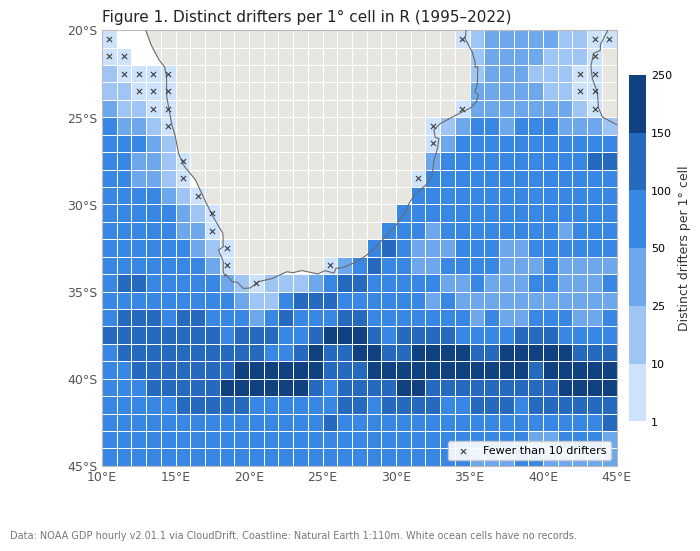

1° cells: occupied 649 of 875 | median drifters 71 (10th-90th: 24-138) | >= 10 drifters: 614
2° cells: occupied 178 of 234 | median drifters 116 (25th: 76) | >= 10 drifters: 171


In [ ]:
# Figure 1: distinct drifters per 1° cell in R (slides 15-16: "How many different drifters support each cell?")
import urllib.request
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Polygon

cell = 1
cell_id, n_cols, n_rows = cell_of(lon[in_idx], lat[in_idx], west, east, south, north, cell)
key = np.unique(cell_id.astype(np.int64) * 100_000 + traj_of_obs)
grid = np.bincount(key // 100_000, minlength=n_rows * n_cols).reshape(n_rows, n_cols).astype(float)
grid[grid == 0] = np.nan

# Land polygons, Natural Earth 1:110m (same coastline source as the Week 1 slides)
try:
    url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_land.geojson"
    land = json.load(urllib.request.urlopen(url))
except Exception as e:
    print(f"coastline not loaded ({e!r}); maps drawn without land")
    land = {"features": []}

def draw_land(ax):
    for feat in land["features"]:
        g = feat["geometry"]
        polys = g["coordinates"] if g["type"] == "MultiPolygon" else [g["coordinates"]]
        for p in polys:
            ax.add_patch(Polygon(np.array(p[0]), closed=True, facecolor="#e8e6e1", edgecolor="none", zorder=0))
            ax.add_patch(Polygon(np.array(p[0]), closed=True, fill=False, edgecolor="#6b6a66", linewidth=0.8, zorder=3))

def style_map(ax):
    ax.set_xlim(west, east)
    ax.set_ylim(south, north)
    ax.set_aspect(1 / np.cos(np.deg2rad((north + south) / 2)))
    ax.set_xticks(range(west, east + 1, 5))
    ax.set_yticks(range(south, north + 1, 5))
    ax.set_xticklabels([f"{x}°E" for x in range(west, east + 1, 5)], fontsize=9, color="#555")
    ax.set_yticklabels([f"{-y}°S" for y in range(south, north + 1, 5)], fontsize=9, color="#555")
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_color("#bbb")

# One-hue sequential blue ramp, light = few drifters, dark = many
bins = [1, 10, 25, 50, 100, 150, max(250, int(np.nanmax(grid)) + 1)]
cmap = ListedColormap(["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#104281"])
cmap.set_bad((0, 0, 0, 0))   # transparent, so land shows through
norm = BoundaryNorm(bins, cmap.N)
lon_edges = west + np.arange(n_cols + 1) * cell
lat_edges = south + np.arange(n_rows + 1) * cell

fig, ax = plt.subplots(figsize=(8, 6))
draw_land(ax)
mesh = ax.pcolormesh(lon_edges, lat_edges, grid, cmap=cmap, norm=norm, edgecolor="white", linewidth=0.4, zorder=1)
r, c = np.nonzero(grid < 10)   # cells visited by fewer than 10 distinct drifters
ax.scatter(lon_edges[c] + cell / 2, lat_edges[r] + cell / 2, marker="x", s=14,
           color="#3d3d3a", linewidths=0.8, zorder=4, label="Fewer than 10 drifters")
style_map(ax)
cb = fig.colorbar(mesh, ax=ax, shrink=0.75, pad=0.02)
cb.set_label("Distinct drifters per 1° cell", fontsize=9, color="#333")
cb.ax.tick_params(labelsize=8, length=0)
cb.outline.set_visible(False)
ax.legend(loc="lower right", fontsize=8, frameon=True, framealpha=0.9)
ax.set_title("Figure 1. Distinct drifters per 1° cell in R (1995–2022)", fontsize=11, loc="left", color="#222")
fig.text(0.01, 0.01, "Data: NOAA GDP hourly v2.01.1 via CloudDrift. Coastline: Natural Earth 1:110m. "
         "White ocean cells have no records.", fontsize=7, color="#777")
plt.savefig("fig1_coverage_1deg.png", dpi=200, bbox_inches="tight")
plt.show()

occ = grid[~np.isnan(grid)]
print(f"1° cells: occupied {occ.size} of {n_rows * n_cols} | median drifters {np.median(occ):.0f} "
      f"(10th-90th: {np.percentile(occ, 10):.0f}-{np.percentile(occ, 90):.0f}) | >= 10 drifters: {(occ >= 10).sum()}")
r2 = boxes["R (chosen, Agulhas)"]
print(f"2° cells: occupied {r2['cells_occupied']} of {r2['cells_total']} | median drifters {r2['median_drifters_per_cell']} "
      f"(25th: {r2['p25']}) | >= 10 drifters: {r2['cells_ge10_drifters']}")

## 4. Coverage over years and seasons

Records in R run from 31 Mar 1995 to 31 Oct 2022


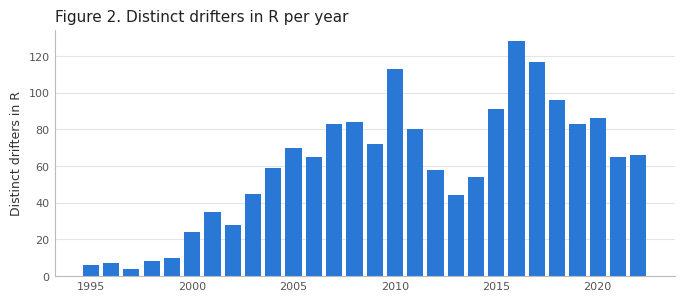

Years with any drifter in R: 28 of 28
Median drifters per year: 65  (min 4 in 1997, max 128 in 2016)
  1995-1999: median 7 drifters per year
  2000-2009: median 62 drifters per year
  2010-2022: median 83 drifters per year

Table 2. Coverage by austral season (1° cells)
      Season  Hourly records  Distinct drifters  Occupied 1° cells  Median drifters per cell  Cells with >= 10 drifters
DJF (summer)          858391                676                634                        18                        533
MAM (autumn)         1012587                704                639                        21                        543
JJA (winter)         1047302                735                637                        21                        560
SON (spring)          930689                714                640                        19                        554


In [ ]:
# Figure 2 + Table 2: coverage across years and seasons (slide 16: "Is coverage sufficient across seasons and years?")
t = pd.DatetimeIndex(t_ns[in_idx])
rec = pd.DataFrame({"traj": traj_of_obs, "year": t.year, "month": t.month})
print(f"Records in R run from {t.min():%d %b %Y} to {t.max():%d %b %Y}")

# ---- Years: distinct drifters present in R each year ----
per_year = rec.groupby("year")["traj"].nunique()
per_year = per_year.reindex(range(per_year.index.min(), per_year.index.max() + 1), fill_value=0)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(per_year.index, per_year.values, width=0.8, color="#2a78d6")
ax.set_ylabel("Distinct drifters in R", fontsize=9, color="#333")
ax.set_title("Figure 2. Distinct drifters in R per year", fontsize=11, loc="left", color="#222")
ax.tick_params(labelsize=8, length=0, colors="#555")
ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
ax.set_axisbelow(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["left", "bottom"]:
    ax.spines[s].set_color("#bbb")
plt.savefig("fig2_drifters_per_year.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Years with any drifter in R: {(per_year > 0).sum()} of {len(per_year)}")
print(f"Median drifters per year: {per_year.median():.0f}  (min {per_year.min()} in {per_year.idxmin()}, "
      f"max {per_year.max()} in {per_year.idxmax()})")
for a, b in [(1995, 1999), (2000, 2009), (2010, 2022)]:
    sel = per_year.loc[a:b]
    print(f"  {a}-{b}: median {sel.median():.0f} drifters per year")

# ---- Seasons (austral): DJF summer, MAM autumn, JJA winter, SON spring ----
season_of = {12: "DJF (summer)", 1: "DJF (summer)", 2: "DJF (summer)",
             3: "MAM (autumn)", 4: "MAM (autumn)", 5: "MAM (autumn)",
             6: "JJA (winter)", 7: "JJA (winter)", 8: "JJA (winter)",
             9: "SON (spring)", 10: "SON (spring)", 11: "SON (spring)"}
rec["season"] = rec["month"].map(season_of)
rec["cell"] = cell_id

rows = []
for s in ["DJF (summer)", "MAM (autumn)", "JJA (winter)", "SON (spring)"]:
    sub = rec[rec["season"] == s]
    per_cell = sub.groupby("cell")["traj"].nunique()
    rows.append({"Season": s, "Hourly records": len(sub), "Distinct drifters": sub["traj"].nunique(),
                 "Occupied 1° cells": len(per_cell), "Median drifters per cell": int(per_cell.median()),
                 "Cells with >= 10 drifters": int((per_cell >= 10).sum())})
table2 = pd.DataFrame(rows)
print("\nTable 2. Coverage by austral season (1° cells)")
print(table2.to_string(index=False))

## 5. Drogue status and how drifters end

Drogue-related variables: ['DragAreaAboveDrogue', 'DragAreaOfDrogue', 'DrogueBallast', 'DrogueCenterDepth', 'DrogueDetectSensor', 'DrogueLength', 'DrogueType', 'drogue_lost_date', 'drogue_status']
drogue_lost_date attrs: {'long_name': 'Date and time of drogue loss'}

Drifters entering R: 1149
  drogue-loss date missing (NaT): 4
  lost on or before deployment:   34
  lost after the record ends:     0
  days drogued after deployment: median 173, 25th-75th 79-360

Five example drifters:
             id     deploy drogue_lost        end
          89770 2010-02-20  2010-04-13 2012-03-22
300234063896840 2017-03-26  2017-06-16 2018-01-27
          70812 2008-02-03  2008-02-23 2011-11-25
         118513 2013-01-01  2013-09-08 2017-01-29
300234064876500        NaT  2021-05-02 2022-02-24

Share of records in R that are drogued (from drogue_lost_date): 33.3%
Share of drifters in R with at least one drogued record in R:  49.4%
Share from the per-record drogue_status flag:                  33.4%
Ag

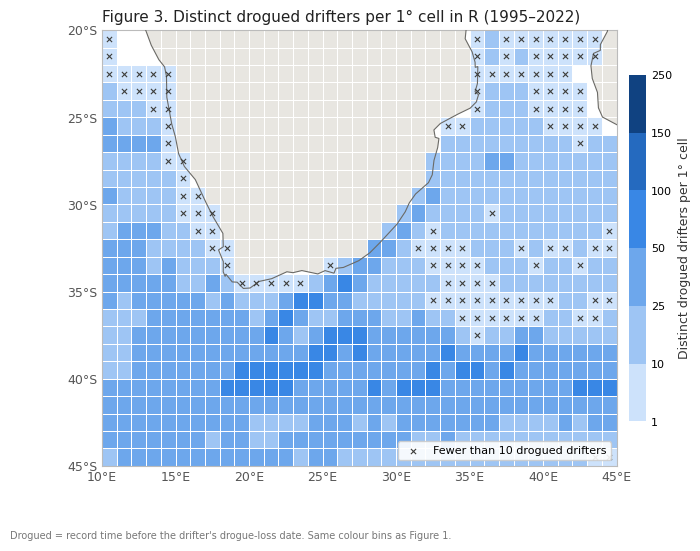

In [ ]:
# Drogue check + Figure 3: drogued drifters per 1° cell
# ---- Part 1: check how the drogue information is stored ----
print("Drogue-related variables:", [v for v in ds.variables if "drog" in v.lower()])
print("drogue_lost_date attrs:", dict(ds.drogue_lost_date.attrs))

meta = pd.DataFrame({
    "id":          ds.id.values[tr],
    "deploy":      as_time(ds.deploy_date.values)[tr],
    "drogue_lost": as_time(ds.drogue_lost_date.values)[tr],
    "end":         as_time(ds.end_date.values)[tr],
})
print(f"\nDrifters entering R: {len(meta)}")
print(f"  drogue-loss date missing (NaT): {meta.drogue_lost.isna().sum()}")
print(f"  lost on or before deployment:   {(meta.drogue_lost <= meta.deploy).sum()}")
print(f"  lost after the record ends:     {(meta.drogue_lost > meta.end).sum()}")
days = (meta.drogue_lost - meta.deploy).dt.days
print(f"  days drogued after deployment: median {days.median():.0f}, "
      f"25th-75th {days.quantile(.25):.0f}-{days.quantile(.75):.0f}")
print("\nFive example drifters:")
print(meta.sample(min(5, len(meta)), random_state=1).to_string(index=False))

# ---- Part 2: drogued share of records in R, two ways ----
t_in = t_ns[in_idx].astype("datetime64[ns]")
lost_rec = as_time(ds.drogue_lost_date.values).astype("datetime64[ns]")[traj_of_obs]
drogued = pd.notnull(lost_rec) & (t_in < lost_rec)
print(f"\nShare of records in R that are drogued (from drogue_lost_date): {drogued.mean():.1%}")
print(f"Share of drifters in R with at least one drogued record in R:  "
      f"{len(np.unique(traj_of_obs[drogued])) / len(tr):.1%}")
if "drogue_status" in ds.variables:
    ds_flag = ds.drogue_status.values[in_idx].astype(bool)
    print(f"Share from the per-record drogue_status flag:                  {ds_flag.mean():.1%}")
    print(f"Agreement between the two methods:                             {(ds_flag == drogued).mean():.1%}")

# ---- Part 3: distinct drogued drifters per 1° cell ----
def drifters_per_cell(mask):
    k = np.unique(cell_id[mask].astype(np.int64) * 100_000 + traj_of_obs[mask])
    g = np.bincount(k // 100_000, minlength=n_rows * n_cols).reshape(n_rows, n_cols).astype(float)
    g[g == 0] = np.nan
    return g

g_all = drifters_per_cell(np.ones(len(in_idx), bool))
g_drg = drifters_per_cell(drogued)
for name, g in [("All drifters", g_all), ("Drogued only", g_drg)]:
    occ = g[~np.isnan(g)]
    print(f"\n{name}: {occ.size} occupied cells | median {np.median(occ):.0f} "
          f"(10th-90th {np.percentile(occ, 10):.0f}-{np.percentile(occ, 90):.0f}) | "
          f">= 10 drifters: {(occ >= 10).sum()} | fewer than 10: {(occ < 10).sum()}")
lost_cells = np.nansum((g_all >= 10) & ~(g_drg >= 10))
print(f"Cells with >= 10 drifters overall but < 10 drogued drifters: {int(lost_cells)}")

# ---- Figure 3: same style and colour bins as Figure 1, drogued drifters only ----
fig, ax = plt.subplots(figsize=(8, 6))
draw_land(ax)
mesh = ax.pcolormesh(lon_edges, lat_edges, g_drg, cmap=cmap, norm=norm, edgecolor="white", linewidth=0.4, zorder=1)
r, c = np.nonzero(g_drg < 10)
ax.scatter(lon_edges[c] + cell / 2, lat_edges[r] + cell / 2, marker="x", s=14, color="#3d3d3a",
           linewidths=0.8, zorder=4, label="Fewer than 10 drogued drifters")
style_map(ax)
cb = fig.colorbar(mesh, ax=ax, shrink=0.75, pad=0.02)
cb.set_label("Distinct drogued drifters per 1° cell", fontsize=9, color="#333")
cb.ax.tick_params(labelsize=8, length=0)
cb.outline.set_visible(False)
ax.legend(loc="lower right", fontsize=8, frameon=True, framealpha=0.9)
ax.set_title("Figure 3. Distinct drogued drifters per 1° cell in R (1995–2022)", fontsize=11, loc="left", color="#222")
fig.text(0.01, 0.01, "Drogued = record time before the drifter's drogue-loss date. Same colour bins as Figure 1.",
         fontsize=7, color="#777")
plt.savefig("fig3_drogued_1deg.png", dpi=200, bbox_inches="tight")
plt.show()

**How we read `typedeath`**

- **0 still alive** — censored: still drifting; the record ends only because the data release has a cut-off date
- **1 ran aground** — ❗️ real endpoint: the flow carried it ashore (e.g. oil washing up on a beach)
- **2 picked up by vessel** — censored: removed by people, unrelated to the flow; it would have kept drifting
- **3 stop transmitting** — censored: transmitter failed, drifter still at sea. ⚠️ Near the coast it may actually have run aground
- **4 sporadic transmissions** — censored: still drifting, but positions are patchy and unreliable
- **5 bad batteries** — censored: power ran out, drifter still at sea
- **6 inactive status** — censored: flagged inactive, whereabouts unknown

In [ ]:
# Table 3: how the drifters in R end (slide 16: "Which exits are observed, and which records end too early?")
td = ds.typedeath.values[tr].astype(int)

# Where is each drifter's very last record: inside R or outside?
last_idx = bounds[tr] - 1
ends_in_R = in_box(lon[last_idx], lat[last_idx], west, east, south, north)

meaning = {0: ("still alive", "censored"), 1: ("ran aground", "real endpoint"),
           2: ("picked up by vessel", "censored"), 3: ("stop transmitting", "censored"),
           4: ("sporadic transmissions", "censored"), 5: ("bad batteries", "censored"),
           6: ("inactive status", "censored")}

rows = []
for k, (name, role) in meaning.items():
    m = td == k
    rows.append({"typedeath": k, "Meaning": name, "Treated as": role,
                 "Drifters": int(m.sum()), "Record ends inside R": int((m & ends_in_R).sum())})
table3 = pd.DataFrame(rows)
table3.loc[len(table3)] = ["", "Total", "", int(len(tr)), int(ends_in_R.sum())]
print(f"Table 3. How the {len(tr):,} drifters that enter R end")
print(table3.to_string(index=False))

print(f"\nDrifters whose record ends outside R (they left R first): {(~ends_in_R).sum()} "
      f"({(~ends_in_R).mean():.1%})")
print(f"Ran aground inside R (real endpoints in R): {((td == 1) & ends_in_R).sum()}")
print(f"'Stop transmitting' inside R: {(ends_in_R & (td == 3)).sum()} (some may be unrecorded groundings)")

Table 3. How the 1,149 drifters that enter R end
typedeath                Meaning    Treated as  Drifters  Record ends inside R
        0            still alive      censored        61                    22
        1            ran aground real endpoint       190                    70
        2    picked up by vessel      censored        27                    12
        3      stop transmitting      censored       857                   203
        4 sporadic transmissions      censored         0                     0
        5          bad batteries      censored         1                     0
        6        inactive status      censored        13                     2
                           Total                    1149                   309

Drifters whose record ends outside R (they left R first): 840 (73.1%)
Ran aground inside R (real endpoints in R): 70
'Stop transmitting' inside R: 203 (some may be unrecorded groundings)


## 6. Seven-day pairs for the transition matrix

One origin per day; a drifter that leaves R at any hour in the 7 days counts as an exit even if it comes back, and the exit is labelled by the side of R it crossed (west = towards the Atlantic). Output: `gdp_out/pairs7.csv`.

In [ ]:
# 7-day pairs for the transition matrix (README "Building the pairs")
# - one origin per day (00:00 UTC), not every hour: neighbouring hours are near-duplicates
# - a drifter counts as "exited" if it is outside R at ANY hour in the 7 days,
#   even if it comes back (outside is an absorbing state in the matrix)
# - each exit is labelled by the side of R it crossed: west = towards the Atlantic
# - record ends inside R before day 7 -> pair dropped (we don't know where it went)
# Uses the WHOLE tracks of the drifters that enter R (also outside R), otherwise we couldn't see them leave.
H = 7 * 24                      # 7 days = 168 rows on the hourly grid
DAY = np.int64(86_400 * 10**9)  # one day in nanoseconds

rows_tr = np.concatenate([np.arange(starts[j], bounds[j]) for j in tr])
plon, plat, pt = lon[rows_tr], lat[rows_tr], t_ns[rows_tr]
ptraj = np.repeat(tr, rowsize[tr])
row_end = np.repeat(np.cumsum(rowsize[tr]), rowsize[tr])   # end (exclusive) of each row's drifter block

valid = np.isfinite(plon) & np.isfinite(plat)
inR = valid & in_box(plon, plat, west, east, south, north)
cs = np.concatenate([[0], np.cumsum(valid & ~inR)])        # cs[m] = outside rows among rows 0..m-1

n_cells = int(np.ceil((east - west) / GRID)) * int(np.ceil((north - south) / GRID))
EXIT = {"west": n_cells, "east": n_cells + 1, "south": n_cells + 2, "north": n_cells + 3}
def cell2(i):
    return cell_of(plon[i], plat[i], west, east, south, north, GRID)[0]

# origins: inside R, at 00:00 UTC
o = np.nonzero(inR & (pt % DAY == 0))[0]
last = np.minimum(o + H, row_end[o] - 1)

# did it leave R at any hour in the next 7 days? where did it first leave?
exited = (cs[last + 1] - cs[o + 1]) > 0
first_out = np.searchsorted(cs, cs[o + 1] + 1, side="left") - 1
exited &= (pt[np.where(exited, first_out, o)] - pt[o]) <= 7 * DAY

# if it didn't leave: need a position exactly 7 days later (checked by time, not just row offset)
d = o + H
full = d < row_end[o]
d_safe = np.where(full, d, o)
exact = full & ((pt[d_safe] - pt[o]) == 7 * DAY)
stayed = ~exited & exact & inR[d_safe]
keep = exited | stayed

dest = np.full(len(o), -1)
dest[stayed] = cell2(d[stayed])
fo = first_out[exited]
dest[exited] = np.where(plon[fo] < west, EXIT["west"],
               np.where(plon[fo] > east, EXIT["east"],
               np.where(plat[fo] < south, EXIT["south"], EXIT["north"])))

pairs7 = pd.DataFrame({"origin_cell": cell2(o[keep]), "dest": dest[keep],
                       "traj": ptraj[o[keep]], "time": pd.to_datetime(pt[o[keep]])})
pairs7.to_csv(os.path.join(OUT, "pairs7.csv"), index=False)

n_exit = int(exited.sum())
exit_and_return = int((exited & exact & inR[d_safe]).sum())
per_cell = pairs7.groupby("origin_cell")["traj"].nunique()
pairs_summary = dict(
    daily_origins_in_R=int(len(o)), kept_pairs=int(keep.sum()), dropped_pairs=int((~keep).sum()),
    stayed_in_R=int(stayed.sum()), left_R=n_exit,
    left_by_side={s: int((pairs7.dest == c).sum()) for s, c in EXIT.items()},
    left_and_came_back=exit_and_return,
    cells_with_pairs=int(len(per_cell)), cells_total=n_cells,
    cells_ge10_distinct_drifters=int((per_cell >= 10).sum()),
    median_distinct_drifters_per_cell=int(per_cell.median()) if len(per_cell) else 0,
)
print(json.dumps(pairs_summary, indent=2))
print(f"\n{exit_and_return:,} of {n_exit:,} exits ({exit_and_return / max(n_exit, 1):.1%}) came back by day 7 "
      f"-> these would be counted as 'stayed' if we only looked at day 7")

{
  "daily_origins_in_R": 160500,
  "kept_pairs": 154139,
  "dropped_pairs": 6361,
  "stayed_in_R": 142893,
  "left_R": 11246,
  "left_by_side": {
    "west": 3594,
    "east": 5343,
    "south": 1785,
    "north": 524
  },
  "left_and_came_back": 1448,
  "cells_with_pairs": 177,
  "cells_total": 234,
  "cells_ge10_distinct_drifters": 171,
  "median_distinct_drifters_per_cell": 107
}

1,448 of 11,246 exits (12.9%) came back by day 7 -> these would be counted as 'stayed' if we only looked at day 7


## 7. Save results

In [ ]:
# Save every number the README uses in one file
results = {
    "dataset": {"name": "NOAA Global Drifter Program hourly dataset v2.01.1",
                "access": "clouddrift.datasets.gdp1h()",
                "citation": "Elipot et al. (2022), doi:10.25921/x46c-3620",
                "boundaries": "inclusive (<=)"},
    "data_audit": audit,
    "pipeline_validation_eac": eac,
    "boxes_2deg": boxes,
    "records_in_R": int(len(in_idx)), "drifters_in_R": int(len(tr)),
    "seven_day_pairs": pairs_summary,
}
with open(os.path.join(OUT, "results.json"), "w") as f:
    json.dump(results, f, indent=2, default=int)
print(f"saved {OUT}/results.json and {OUT}/pairs7.csv")

saved gdp_out/results.json and gdp_out/pairs7.csv
